# 12 — Windows Dataset Explorer

A broad survey of `windows.parquet`, the output of `build_windows_dataset.py`.
This plays the same role here that `03_raw_time_series_explorer` played for
the raw event stream: a wide first look across the whole dataset before any
per-family deep dive (a future `13_typing_windows`, `14_gesture_windows`, etc.
would follow the same progression `04`-`09` followed for raw events).

This notebook does **not** select, rank, or filter features. It exists to
show what's actually in the windowed dataset -- coverage, completeness,
per-participant availability, and the shape of a handful of flagship
features per family -- so that decision is made with eyes open, not here.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                      'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/windows.parquet",
               "data/processed/windows.parquet",
               "windows.parquet",
               "/mnt/user-data/uploads/windows.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no windows.parquet found; tried {_CANDIDATES}")
w = pd.read_parquet(_src)
print(f"Loaded {_src}")
print(f"{w.shape[0]:,} windows x {w.shape[1]:,} columns")

PARTICIPANTS = sorted(w['participantId'].unique())
_PALETTE = plt.get_cmap('tab20').colors
_PCOLOR = {p: _PALETTE[i % len(_PALETTE)] for i, p in enumerate(PARTICIPANTS)}
def pcolor(p):
    return _PCOLOR.get(p, '0.5')

METADATA_COLS = [c for c in w.columns if c.endswith(('_afforded', '_observed', '_straddle_conflict'))] + \
    ['sessionId', 'participantId', 'deviceFamily', 'window_index', 'window_start_s', 'window_end_s',
     'taskIndex', 'taskType', 'activeArea', 'task_pass', 'task_start_s', 'task_end_s', 'task_boundary_straddle']
FAMILIES = {
    'typing':   [c for c in w.columns if c.startswith('typing_') and c not in METADATA_COLS],
    'tap':      [c for c in w.columns if c.startswith('tap_') and c not in METADATA_COLS],
    'gesture':  [c for c in w.columns if c.startswith('gesture_') and c not in METADATA_COLS],
    'coupling': [c for c in w.columns if c.startswith('coupling_')],
    'motion':   [c for c in w.columns if c.startswith('motion_')],
}
N_FEATURE_COLS = sum(len(v) for v in FAMILIES.values())
print(f"\n{len(PARTICIPANTS)} participants, {N_FEATURE_COLS} behavioural feature columns "
      f"across {len(FAMILIES)} families")


Loaded ../../data/processed/windows.parquet
2,883 windows x 596 columns

17 participants, 574 behavioural feature columns across 5 families


## 1. Structural overview

Basic shape, session/participant counts, and the device split -- the same
sanity checks every raw-data notebook in this project opens with, now
applied to the windowed output instead of raw events.


In [2]:
print(f"windows          : {len(w):,}")
print(f"sessions         : {w['sessionId'].nunique()}")
print(f"participants     : {w['participantId'].nunique()}")
print(f"window length    : {(w['window_end_s'] - w['window_start_s']).median():.1f}s (median)")
print(f"window stride    : {w.groupby('sessionId')['window_start_s'].apply(lambda s: s.sort_values().diff().median()).median():.2f}s (median)")
print()
dev = w.groupby('deviceFamily')['sessionId'].nunique()
print("sessions by device family:")
print(dev.to_string())
print()
print("memory footprint of this table:", f"{w.memory_usage(deep=True).sum() / 1e6:.1f} MB")


windows          : 2,883
sessions         : 78
participants     : 17
window length    : 15.0s (median)
window stride    : 7.50s (median)

sessions by device family:
deviceFamily
desktop     2
mobile     76

memory footprint of this table: 14.4 MB


## 2. Windows per session and per participant

How much data each session and each participant actually contributes to
this table. Uneven contribution here is exactly the kind of thing that
matters for the exposure-confound discipline established earlier in this
project -- worth seeing directly, not assuming it's even.


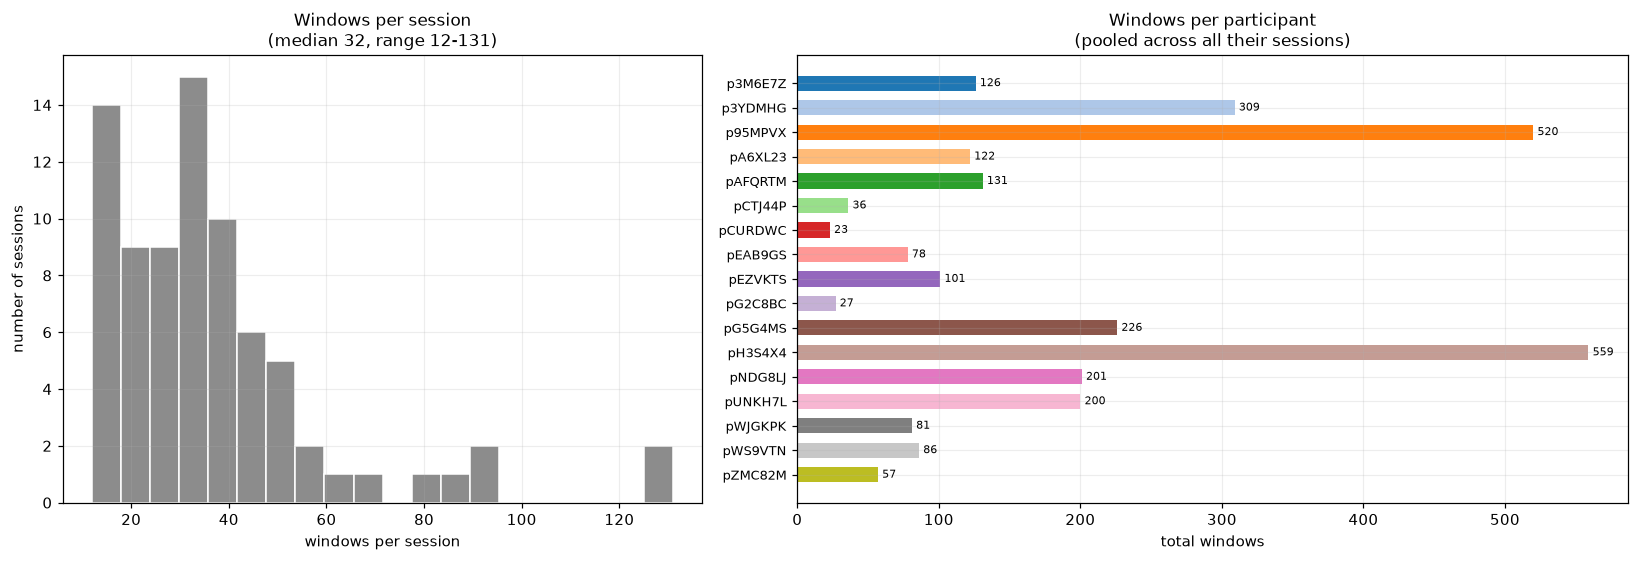

In [3]:
per_session = w.groupby('sessionId').size()
per_participant = w.groupby('participantId').size().reindex(PARTICIPANTS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={'width_ratios': [1, 1.3]})

ax = axes[0]
ax.hist(per_session, bins=20, color='0.55', edgecolor='white')
ax.set_xlabel("windows per session")
ax.set_ylabel("number of sessions")
ax.set_title(f"Windows per session\n(median {per_session.median():.0f}, "
             f"range {per_session.min()}-{per_session.max()})")

ax = axes[1]
y = np.arange(len(per_participant))
ax.barh(y, per_participant.values, color=[pcolor(p) for p in per_participant.index], height=0.62)
ax.set_yticks(y); ax.set_yticklabels(per_participant.index, fontsize=8.5); ax.invert_yaxis()
ax.set_xlabel("total windows")
ax.set_title("Windows per participant\n(pooled across all their sessions)")
for i, p in enumerate(per_participant.index):
    ax.text(per_participant[p] + 3, i, f"{per_participant[p]}", va='center', fontsize=7.5)

plt.tight_layout(); plt.show(); plt.close(fig)


## 3. Task-affordance, observed, and straddle-conflict coverage

The three discrete modalities (typing/tapping/scrolling) each carry three
flags per window: **afforded** (could this modality happen here, from task
context), **observed** (did it actually happen in this window), and
**straddle_conflict** (does this window span two tasks that disagree on
whether this modality is afforded, making its features unsafe to compute).

Typing is structurally rarer than tapping/scrolling (confirmed here, not
assumed) -- worth seeing the actual magnitude of that gap before treating
any typing feature's sparsity as surprising later.


           afforded_frac  observed_frac  straddle_conflict_frac
modality                                                       
typing             0.456          0.444                   0.539
tapping            1.000          0.940                   0.000
scrolling          1.000          0.939                   0.000


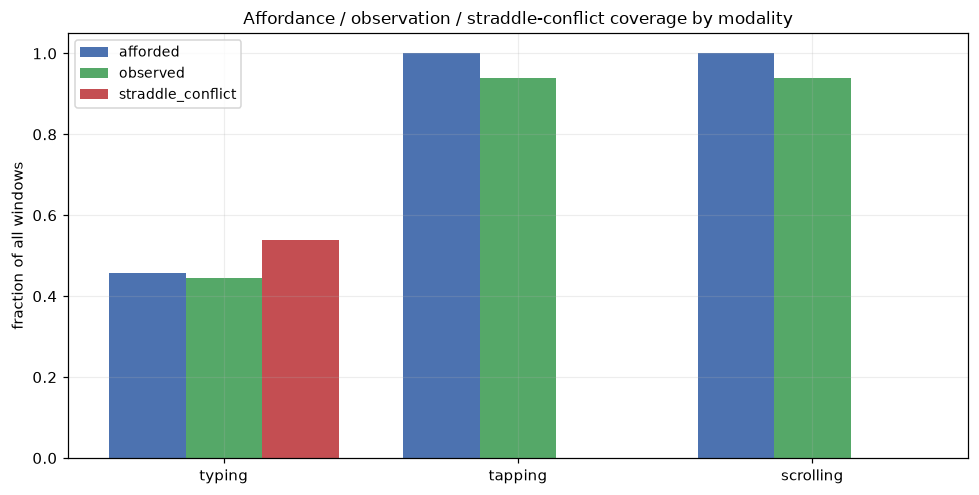

In [4]:
mods = ['typing', 'tapping', 'scrolling']
rows = []
for mod in mods:
    afforded = (w[f'{mod}_afforded'] == True).mean()
    observed = w[f'{mod}_observed'].mean()
    straddle = (w[f'{mod}_straddle_conflict'] == True).mean()
    rows.append({'modality': mod, 'afforded_frac': afforded, 'observed_frac': observed,
                 'straddle_conflict_frac': straddle})
cov = pd.DataFrame(rows).set_index('modality')
print(cov.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4.6))
x = np.arange(len(mods))
width = 0.26
ax.bar(x - width, cov['afforded_frac'], width, label='afforded', color='#4c72b0')
ax.bar(x,          cov['observed_frac'], width, label='observed', color='#55a868')
ax.bar(x + width,  cov['straddle_conflict_frac'], width, label='straddle_conflict', color='#c44e52')
ax.set_xticks(x); ax.set_xticklabels(mods)
ax.set_ylabel("fraction of all windows")
ax.set_title("Affordance / observation / straddle-conflict coverage by modality")
ax.legend()
plt.tight_layout(); plt.show(); plt.close(fig)


## 4. Feature family sizes and completeness

Column counts per family, and how non-null rates are distributed *within*
each family. A family with a wide spread of non-null rates (some columns
near-universal, others rare) is exactly what the maximalist
generate-everything-then-filter approach is supposed to produce --
worth seeing that shape directly rather than assuming uniform coverage.


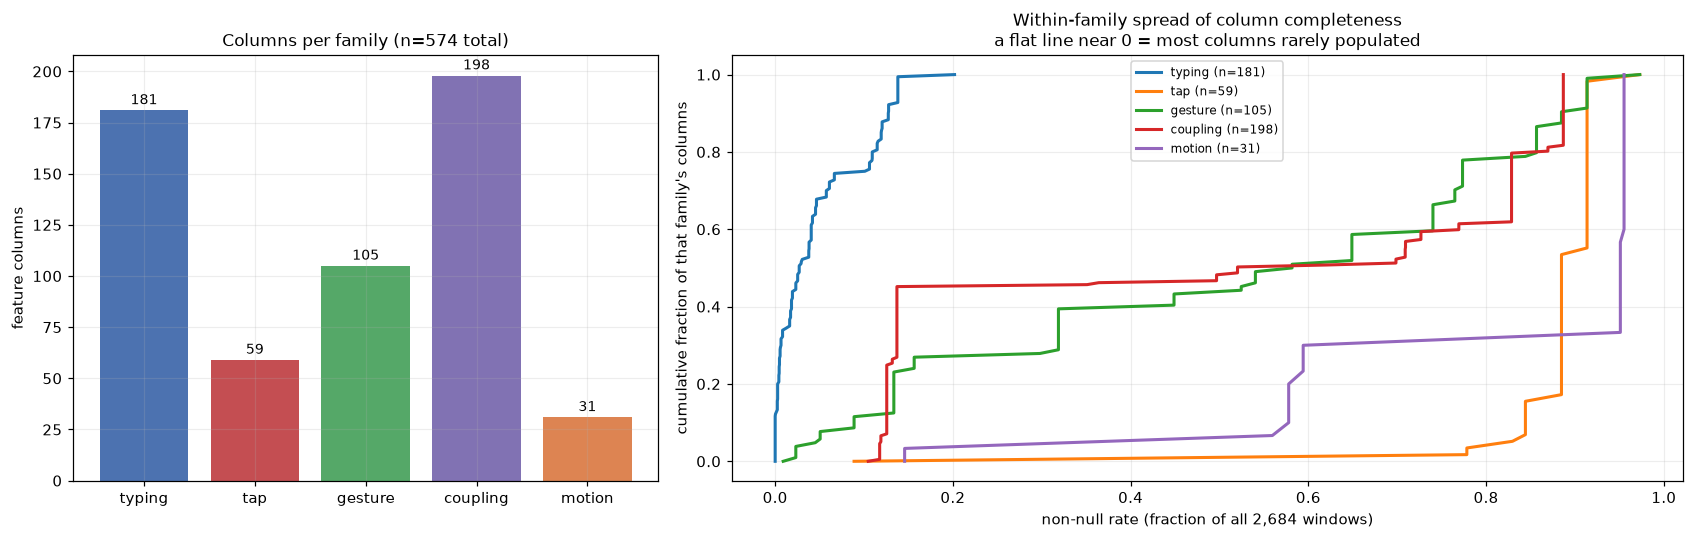

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5), gridspec_kw={'width_ratios': [0.8, 1.3]})

ax = axes[0]
names = list(FAMILIES.keys())
counts = [len(FAMILIES[n]) for n in names]
ax.bar(names, counts, color=['#4c72b0', '#c44e52', '#55a868', '#8172b3', '#dd8452'])
for i, c in enumerate(counts):
    ax.text(i, c + 3, str(c), ha='center', fontsize=9)
ax.set_ylabel("feature columns")
ax.set_title(f"Columns per family (n={sum(counts)} total)")

ax = axes[1]
for name, cols in FAMILIES.items():
    rates = w[cols].notna().mean().to_numpy()
    rates_sorted = np.sort(rates)
    ax.plot(rates_sorted, np.linspace(0, 1, len(rates_sorted)),
            label=f"{name} (n={len(cols)})", lw=2)
ax.set_xlabel("non-null rate (fraction of all 2,684 windows)")
ax.set_ylabel("cumulative fraction of that family's columns")
ax.set_title("Within-family spread of column completeness\n"
              "a flat line near 0 = most columns rarely populated")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show(); plt.close(fig)


## 5. Per-participant family eligibility -- honest availability reporting

Not every participant contributes equally to every family. Typing
especially depends on task affordance, which is uniform across
participants by task design -- but actual keystroke *volume* within
afforded windows is a personal trait, and desktop-only participants
contribute zero tap/gesture windows entirely (touchstart doesn't fire on
desktop pointer input). Named explicitly here rather than silently
producing NaN.


In [6]:
elig_rows = []
for p in PARTICIPANTS:
    sub = w[w['participantId'] == p]
    row = {'participant': p, 'n_windows': len(sub),
           'device': sub['deviceFamily'].iloc[0] if len(sub) else 'unknown'}
    for mod, prefix in [('typing', 'typing'), ('tapping', 'tap'), ('tapping', 'gesture')]:
        pass
    typing_elig = ((sub['typing_afforded'] == True) & (~sub['typing_straddle_conflict'].fillna(False))).sum()
    tap_elig = ((sub['tapping_afforded'] == True) & (~sub['tapping_straddle_conflict'].fillna(False))).sum()
    row['typing_eligible'] = typing_elig
    row['tap_gesture_eligible'] = tap_elig
    row['typing_dwell_populated'] = sub['typing_dwell_ms_mean'].notna().sum() if 'typing_dwell_ms_mean' in sub else 0
    row['tap_count_populated'] = sub['tap_count'].notna().sum() if 'tap_count' in sub else 0
    elig_rows.append(row)
elig = pd.DataFrame(elig_rows).set_index('participant')
print(elig.to_string())

zero_typing = elig.index[elig['typing_dwell_populated'] == 0].tolist()
zero_tap = elig.index[elig['tap_count_populated'] == 0].tolist()
print()
if zero_typing:
    print(f"Participants with ZERO populated typing windows: {', '.join(zero_typing)}")
if zero_tap:
    print(f"Participants with ZERO populated tap windows: {', '.join(zero_tap)}")
if not zero_typing and not zero_tap:
    print("Every participant has at least some populated windows in both typing and tap.")


             n_windows   device  typing_eligible  tap_gesture_eligible  typing_dwell_populated  tap_count_populated
participant                                                                                                        
p3M6E7Z            126   mobile               59                   125                      32                  125
p3YDMHG            309   mobile               61                   300                      56                  300
p95MPVX            520   mobile              109                   508                      56                  508
pA6XL23            122   mobile               11                   118                      10                  118
pAFQRTM            131   mobile               51                   129                      28                  129
pCTJ44P             36   mobile               11                    35                       8                   35
pCURDWC             23  desktop                1                    22  

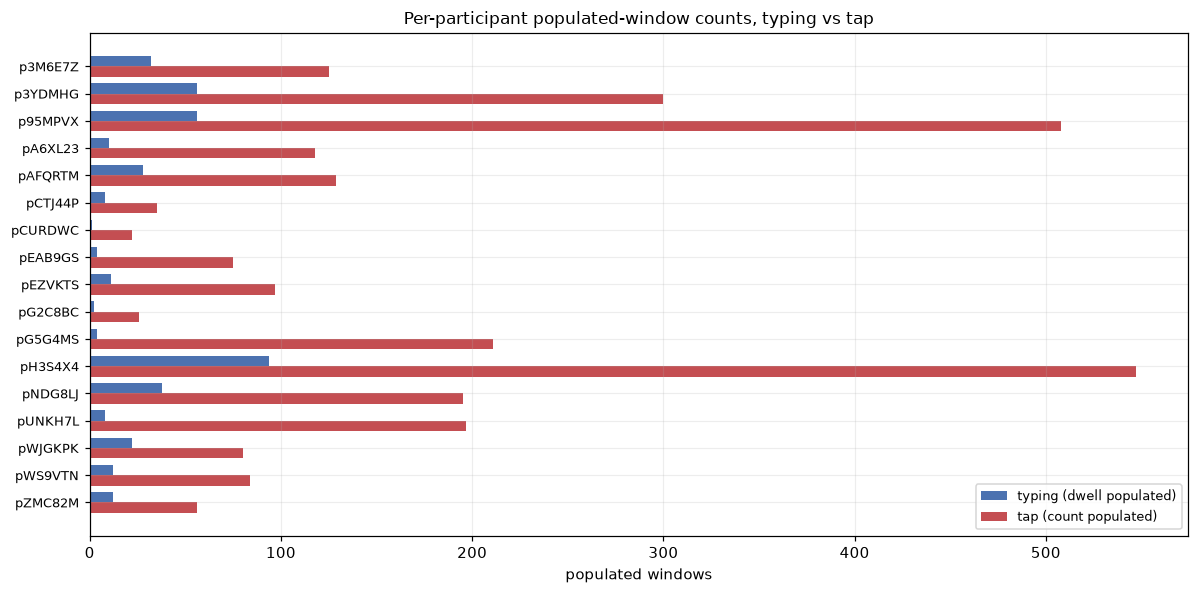

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
y = np.arange(len(elig))
w1 = 0.38
ax.barh(y - w1/2, elig['typing_dwell_populated'], height=w1, color='#4c72b0', label='typing (dwell populated)')
ax.barh(y + w1/2, elig['tap_count_populated'], height=w1, color='#c44e52', label='tap (count populated)')
ax.set_yticks(y); ax.set_yticklabels(elig.index, fontsize=8.5); ax.invert_yaxis()
for i, p in enumerate(elig.index):
    if elig.loc[p, 'typing_dwell_populated'] == 0:
        ax.text(1, i - w1/2, "cannot be measured", va='center', fontsize=7.5, color='#c44e52')
    if elig.loc[p, 'tap_count_populated'] == 0:
        ax.text(1, i + w1/2, "cannot be measured", va='center', fontsize=7.5, color='#c44e52')
ax.set_xlabel("populated windows")
ax.set_title("Per-participant populated-window counts, typing vs tap")
ax.legend(fontsize=8.5, loc='lower right')
plt.tight_layout(); plt.show(); plt.close(fig)


## 6. Flagship feature distributions, by participant

One representative feature per family, shown as a per-participant ECDF
(the same plotting convention used throughout the raw-data notebooks) --
not to draw conclusions about separability, just to see what each
family's signal actually looks like at the window level.


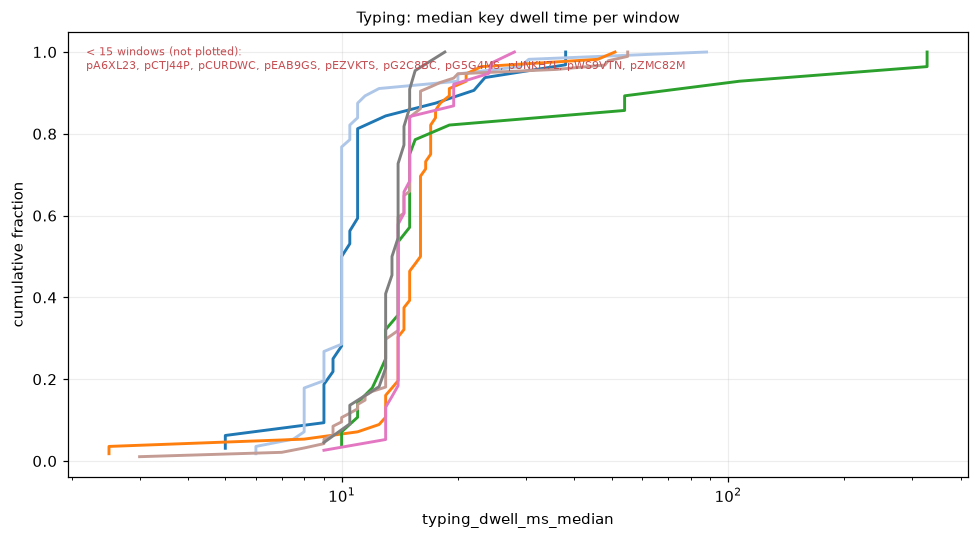

In [8]:
def plot_ecdf_by_participant(col, title, xscale='linear', min_n=15):
    fig, ax = plt.subplots(figsize=(9, 5))
    thin = []
    for p in PARTICIPANTS:
        v = w.loc[w['participantId'] == p, col].dropna().to_numpy()
        if len(v) < min_n:
            if len(v) > 0:
                thin.append(p)
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    if xscale == 'log':
        ax.set_xscale('log')
    ax.set_xlabel(col)
    ax.set_ylabel("cumulative fraction")
    ax.set_title(title, fontsize=10)
    if thin:
        ax.text(0.02, 0.97, f"< {min_n} windows (not plotted):\n" + ", ".join(thin),
                transform=ax.transAxes, va='top', fontsize=7.5, color='#c44e52')
    plt.tight_layout(); plt.show(); plt.close(fig)

plot_ecdf_by_participant('typing_dwell_ms_median',
                          "Typing: median key dwell time per window", xscale='log')


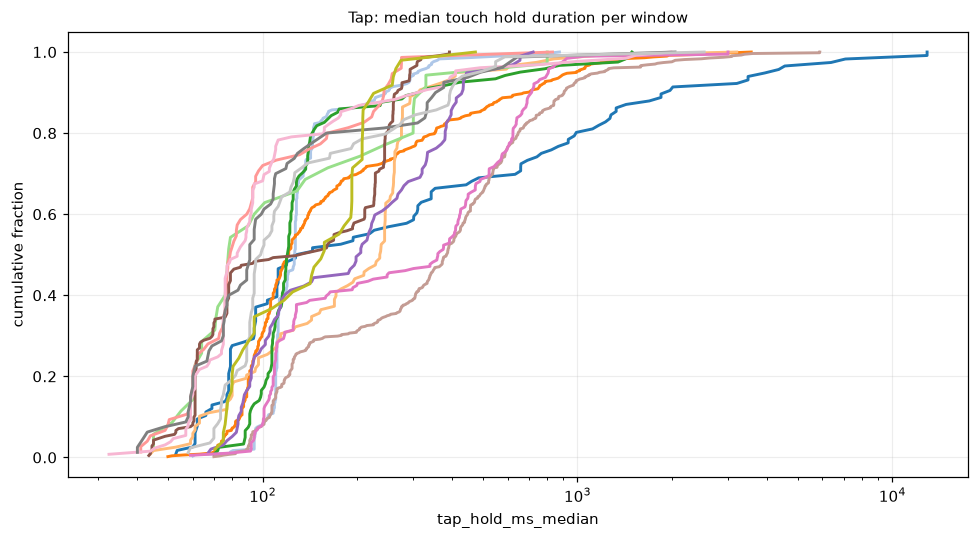

In [9]:
plot_ecdf_by_participant('tap_hold_ms_median',
                          "Tap: median touch hold duration per window", xscale='log')


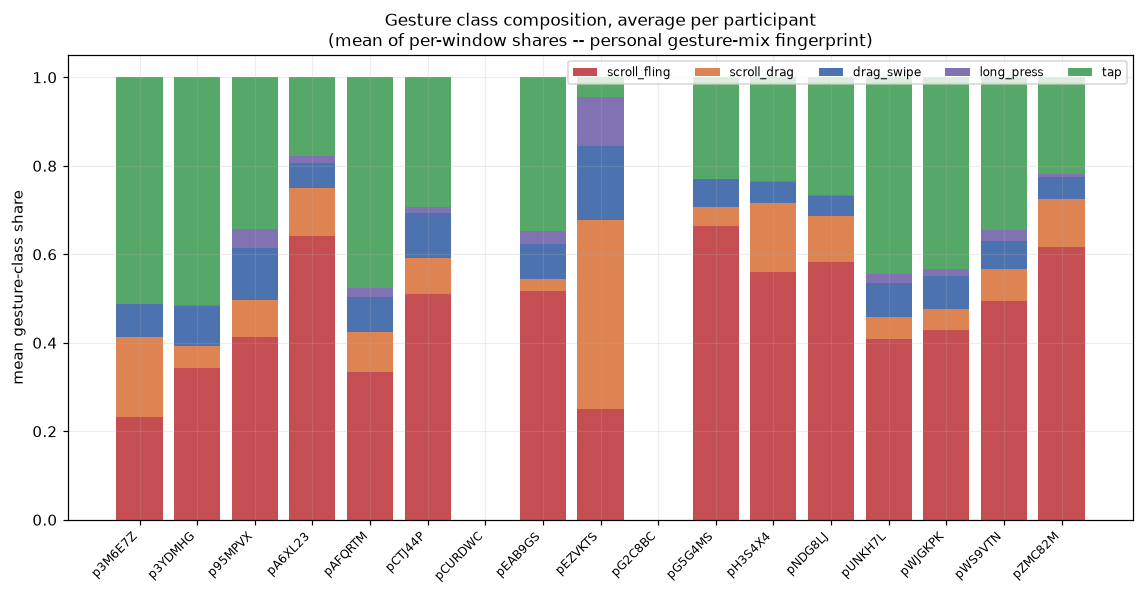

In [10]:
fig, ax = plt.subplots(figsize=(10.5, 5.5))
share_cols = [c for c in w.columns if c.startswith('gesture_share_')]
gest_by_p = w.groupby('participantId')[share_cols].mean().reindex(PARTICIPANTS)
gest_by_p.columns = [c.replace('gesture_share_', '') for c in gest_by_p.columns]
gest_by_p = gest_by_p.fillna(0)
x_pos = np.arange(len(gest_by_p))
bottom = np.zeros(len(gest_by_p))
gest_colors = {'scroll_fling': '#c44e52', 'scroll_drag': '#dd8452', 'drag_swipe': '#4c72b0',
               'long_press': '#8172b3', 'tap': '#55a868'}
for cls in gest_by_p.columns:
    ax.bar(x_pos, gest_by_p[cls], bottom=bottom, color=gest_colors.get(cls, '0.5'), label=cls)
    bottom += gest_by_p[cls].to_numpy()
ax.set_xticks(x_pos)
ax.set_xticklabels(gest_by_p.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("mean gesture-class share")
ax.set_title("Gesture class composition, average per participant\n"
              "(mean of per-window shares -- personal gesture-mix fingerprint)")
ax.legend(fontsize=8, loc='upper right', ncol=5)
plt.tight_layout(); plt.show(); plt.close(fig)


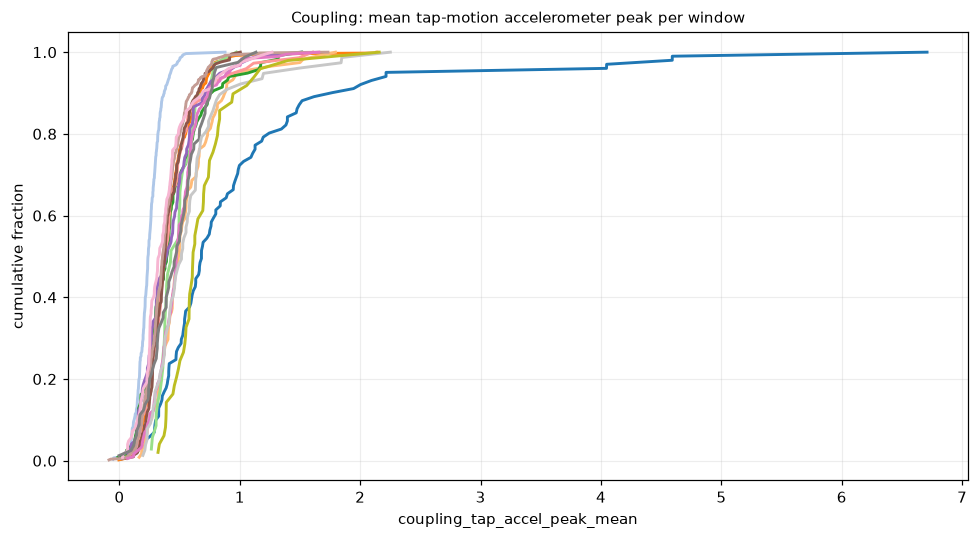

In [11]:
plot_ecdf_by_participant('coupling_tap_accel_peak_mean',
                          "Coupling: mean tap-motion accelerometer peak per window")


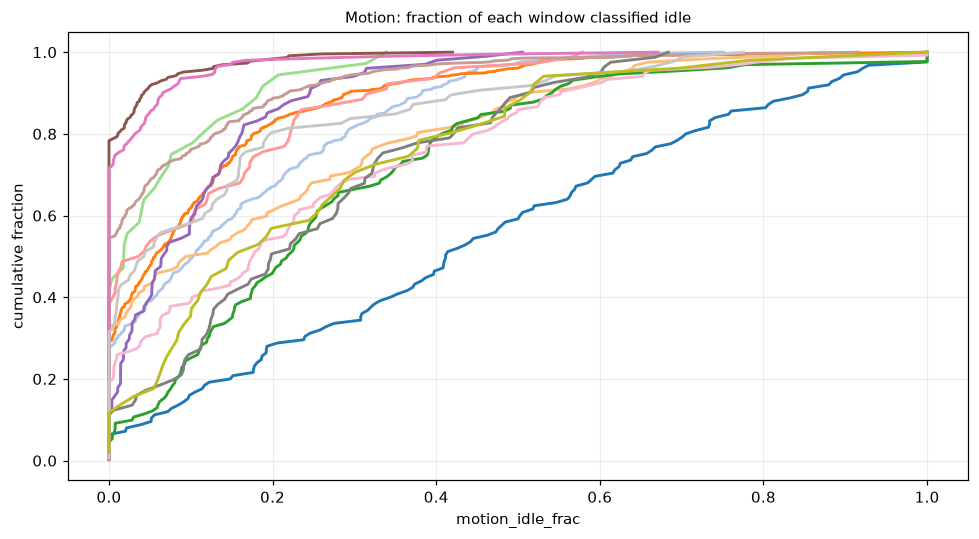

In [12]:
plot_ecdf_by_participant('motion_idle_frac',
                          "Motion: fraction of each window classified idle", min_n=5)


## 7. Session-count distribution -- evaluation readiness

Under P1's session-safe train/enrol/probe assignment rule (1 session ->
training only, 2 -> enrol/probe with no training contribution, 3+ ->
all three roles), a participant's session count determines what role
they can play in evaluation. Shown directly here since it constrains
what any eventual model's evaluation set can actually look like,
independent of anything about the features themselves.


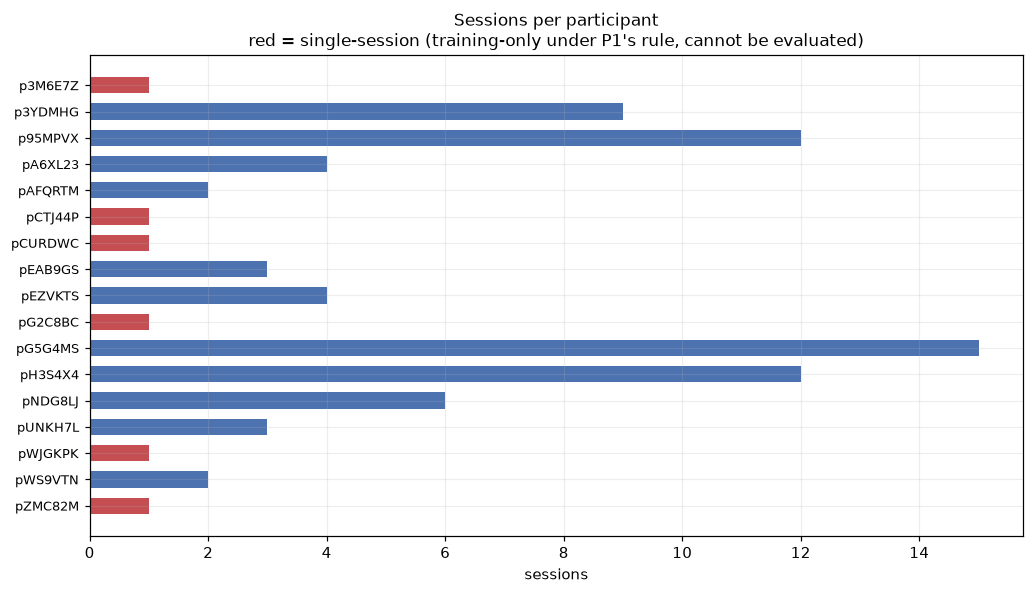

6 of 17 participants have exactly 1 session.
Evaluable (2+ sessions) participant pool: 11


In [13]:
sessions_per_p = w.groupby('participantId')['sessionId'].nunique().reindex(PARTICIPANTS)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
y = np.arange(len(sessions_per_p))
colors = ['#c44e52' if n == 1 else '#4c72b0' for n in sessions_per_p]
ax.barh(y, sessions_per_p.values, color=colors, height=0.62)
ax.set_yticks(y); ax.set_yticklabels(sessions_per_p.index, fontsize=8.5); ax.invert_yaxis()
ax.set_xlabel("sessions")
ax.set_title("Sessions per participant\n"
              "red = single-session (training-only under P1's rule, cannot be evaluated)")
plt.tight_layout(); plt.show(); plt.close(fig)

n_single = int((sessions_per_p == 1).sum())
print(f"{n_single} of {len(sessions_per_p)} participants have exactly 1 session.")
print(f"Evaluable (2+ sessions) participant pool: {len(sessions_per_p) - n_single}")


## 8. Column health audit -- fully-empty and near-empty columns

Documenting the sparse tail directly rather than silently dropping it.
These are exactly what the maximalist generate-everything-then-filter
approach is expected to produce at the extreme end -- rare feature
combinations (e.g. an uncommon key-class transition pair) that
essentially never accumulate enough same-window observations across a
72-session cohort. Reason is preserved per column family, not just a
bare list.


In [14]:
all_feature_cols = [c for cols in FAMILIES.values() for c in cols]
notnull_rates = w[all_feature_cols].notna().mean().sort_values()

fully_empty = notnull_rates[notnull_rates == 0]
near_empty = notnull_rates[(notnull_rates > 0) & (notnull_rates < 0.01)]

print(f"Fully-empty columns (0% populated): {len(fully_empty)} of {len(all_feature_cols)}")
if len(fully_empty):
    print(fully_empty.index.tolist())

print(f"\nNear-empty columns (<1% populated): {len(near_empty)}")
if len(near_empty):
    print(near_empty.round(4).to_string())


Fully-empty columns (0% populated): 22 of 574
['typing_transition_space_backspace_ms_std', 'typing_transition_space_backspace_ms_p95', 'typing_transition_backspace_letter_ms_slope', 'typing_transition_backspace_space_ms_mean', 'typing_transition_backspace_space_ms_std', 'typing_transition_backspace_space_ms_median', 'typing_transition_backspace_space_ms_iqr', 'typing_transition_backspace_space_ms_p95', 'typing_transition_backspace_space_ms_max', 'typing_transition_backspace_space_ms_n', 'typing_transition_backspace_space_ms_cv', 'typing_transition_backspace_space_ms_slope', 'typing_transition_space_backspace_ms_iqr', 'typing_transition_space_space_ms_slope', 'typing_transition_space_space_ms_cv', 'typing_transition_space_space_ms_p95', 'typing_transition_space_space_ms_iqr', 'typing_transition_space_space_ms_std', 'typing_dwell_punct_or_symbol_ms_slope', 'typing_transition_letter_backspace_ms_slope', 'typing_transition_space_backspace_ms_cv', 'typing_transition_space_backspace_ms_slope

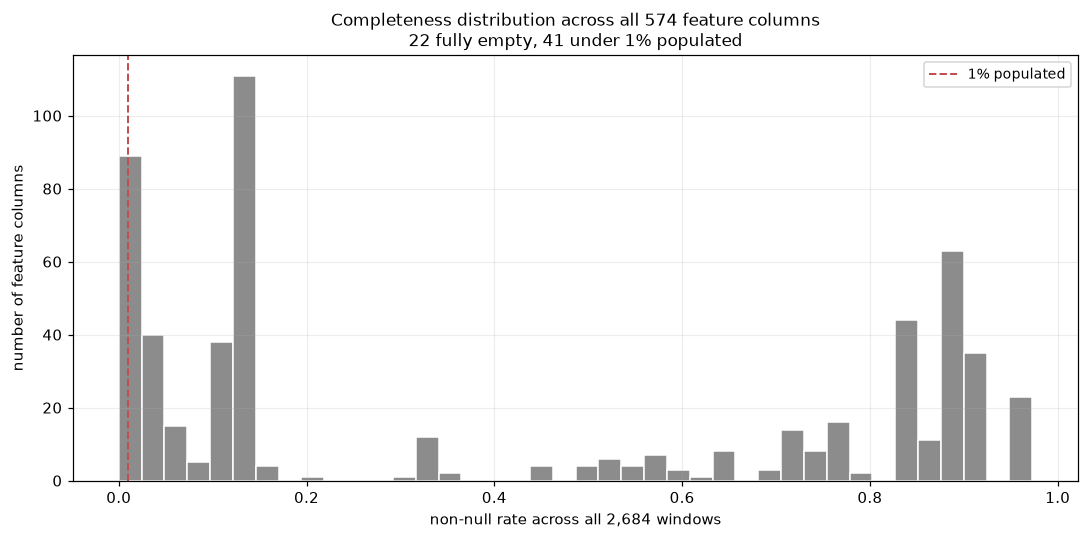

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(notnull_rates, bins=40, color='0.55', edgecolor='white')
ax.axvline(0.01, color='#c44e52', ls='--', lw=1.3, label='1% populated')
ax.set_xlabel("non-null rate across all 2,684 windows")
ax.set_ylabel("number of feature columns")
ax.set_title(f"Completeness distribution across all {len(all_feature_cols)} feature columns\n"
             f"{len(fully_empty)} fully empty, {len(near_empty)} under 1% populated")
ax.legend()
plt.tight_layout(); plt.show(); plt.close(fig)


## 9. Straddle-conflict cost, typing specifically

Typing is the only modality where straddle-conflict actually excludes a
meaningful share of windows (tapping/scrolling's conflict rate is 0% --
see Section 3). Breaking down exactly where typing-eligible windows are
lost: not afforded at all, afforded but conflicted, or genuinely eligible.


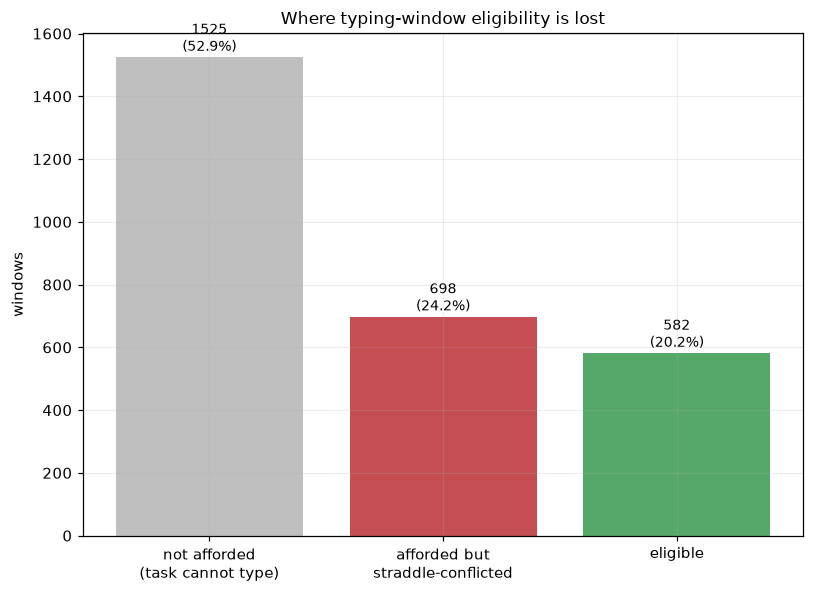

Of 2,883 total windows: 582 (20.2%) are typing-eligible.


In [16]:
not_afforded = (w['typing_afforded'] != True).sum()
afforded_conflict = ((w['typing_afforded'] == True) & (w['typing_straddle_conflict'] == True)).sum()
eligible = ((w['typing_afforded'] == True) & (~w['typing_straddle_conflict'].fillna(False))).sum()

labels = ['not afforded\n(task cannot type)', 'afforded but\nstraddle-conflicted', 'eligible']
values = [not_afforded, afforded_conflict, eligible]
colors = ['0.75', '#c44e52', '#55a868']

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.bar(labels, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v + 20, f"{v}\n({v/len(w):.1%})", ha='center', fontsize=9)
ax.set_ylabel("windows")
ax.set_title("Where typing-window eligibility is lost")
plt.tight_layout(); plt.show(); plt.close(fig)

print(f"Of {len(w):,} total windows: {eligible} ({eligible/len(w):.1%}) are typing-eligible.")


## Open questions

No verdicts here -- these are what this first look raises, not answers:

- **Gesture class imbalance** (Section 6): `scroll_fling` dominates the
  per-participant gesture mix for most people. Worth checking whether
  this reflects genuine behavioural preference or the task design's own
  affordance mix (i.e. is scroll_fling just what most tasks call for).
- **Desktop participants** (Section 5): confirmed to contribute zero
  tap/gesture/coupling windows, as expected structurally, but worth a
  decision on whether they're excluded from those families' modelling
  entirely or handled some other way, given only 2 sessions exist.
- **Near-empty column tail** (Section 8): worth deciding a concrete
  cutoff (e.g. minimum populated-window count) for the eventual
  behavioural-candidate filtering stage, rather than a blanket "0% is
  excluded, everything else is kept" rule.
- **Single-session participants** (Section 7): 
  worth deciding now whether their training-only contribution is
  valuable enough to keep them in the cohort as-is, or whether more
  sessions should be prioritised for them specifically before modelling.
- This notebook only looked at ONE representative feature per family
  (Section 6). A per-family deep dive (mirroring 04-09's structure, but
  built on windows instead of raw events) would be the natural next step
  for typing/tap/gesture/coupling/motion individually.
